In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params_v5
from src.MultiVariateForecaster import MultiVariateForecaster
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    if not y_pred.index.equals(y_true.index):
        y_pred.index = y_true.index
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    for i in range(0, len(target_cols)):
        col = target_cols[i]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        if i != 0:
            neighbor_col = target_cols[i - 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_up']
        if i != len(target_cols) - 1:
            neighbor_col = target_cols[i + 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_down']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))       
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../xgboost/models/xgb_v5'
target_cols = ['48-1 (0)','48-1 (1)','48-1 (2)', '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [10]:
study = search_params_v5(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-19 13:00:55,940] A new study created in memory with name: no-name-ca63c604-cbfd-4e77-a1bf-428dbc1ffe79
[I 2026-05-19 13:01:05,398] Trial 0 finished with value: 0.7349180441945461 and parameters: {'n_estimators': 648, 'learning_rate': 0.25820168729912246, 'max_depth': 7, 'subsample': 0.46187829700179267, 'colsample_bytree': 0.9482971924457356, 'colsample_bylevel': 0.9205404423804694, 'colsample_bynode': 0.6085401968124827, 'reg_alpha': 8.241024408214965, 'reg_lambda': 0.0005841697834101784, 'gamma': 0.00023405118839916867, 'min_child_weight': 5, 'max_delta_step': 14, 'lags_48-1 (0)': 5, 'neighbor_lags_48-1 (0)_down': 2, 'lags_48-1 (1)': 3, 'neighbor_lags_48-1 (1)_up': 1, 'neighbor_lags_48-1 (1)_down': 2, 'lags_48-1 (2)': 4, 'neighbor_lags_48-1 (2)_up': 1, 'neighbor_lags_48-1 (2)_down': 1, 'lags_48-1 (3)': 3, 'neighbor_lags_48-1 (3)_up': 2, 'neighbor_lags_48-1 (3)_down': 3, 'lags_48-1 (4)': 5, 'neighbor_lags_48-1 (4)_up': 1, 'neighbor_lags_48-1 (4)_down': 1, 'lags_48-1 (5)': 2

Лучшие параметры = {'n_estimators': 911, 'learning_rate': 0.009447437239264653, 'max_depth': 8, 'subsample': 0.5683565729464156, 'colsample_bytree': 0.5946502528497097, 'colsample_bylevel': 0.7605996284657772, 'colsample_bynode': 0.7938099063043718, 'reg_alpha': 0.003542474223070499, 'reg_lambda': 0.04702077360780539, 'gamma': 0.019673177290910632, 'min_child_weight': 1, 'max_delta_step': 8, 'lags_48-1 (0)': 3, 'neighbor_lags_48-1 (0)_down': 1, 'lags_48-1 (1)': 3, 'neighbor_lags_48-1 (1)_up': 3, 'neighbor_lags_48-1 (1)_down': 3, 'lags_48-1 (2)': 3, 'neighbor_lags_48-1 (2)_up': 2, 'neighbor_lags_48-1 (2)_down': 2, 'lags_48-1 (3)': 2, 'neighbor_lags_48-1 (3)_up': 1, 'neighbor_lags_48-1 (3)_down': 3, 'lags_48-1 (4)': 2, 'neighbor_lags_48-1 (4)_up': 1, 'neighbor_lags_48-1 (4)_down': 2, 'lags_48-1 (5)': 1, 'neighbor_lags_48-1 (5)_up': 1, 'neighbor_lags_48-1 (5)_down': 3, 'lags_48-1 (6)': 5, 'neighbor_lags_48-1 (6)_up': 3, 'neighbor_lags_48-1 (6)_down': 1, 'lags_48-1 (7)': 5, 'neighbor_lags_

In [11]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v5']

48-1 (0)
RMSE на тесте = 2.9143719973865125


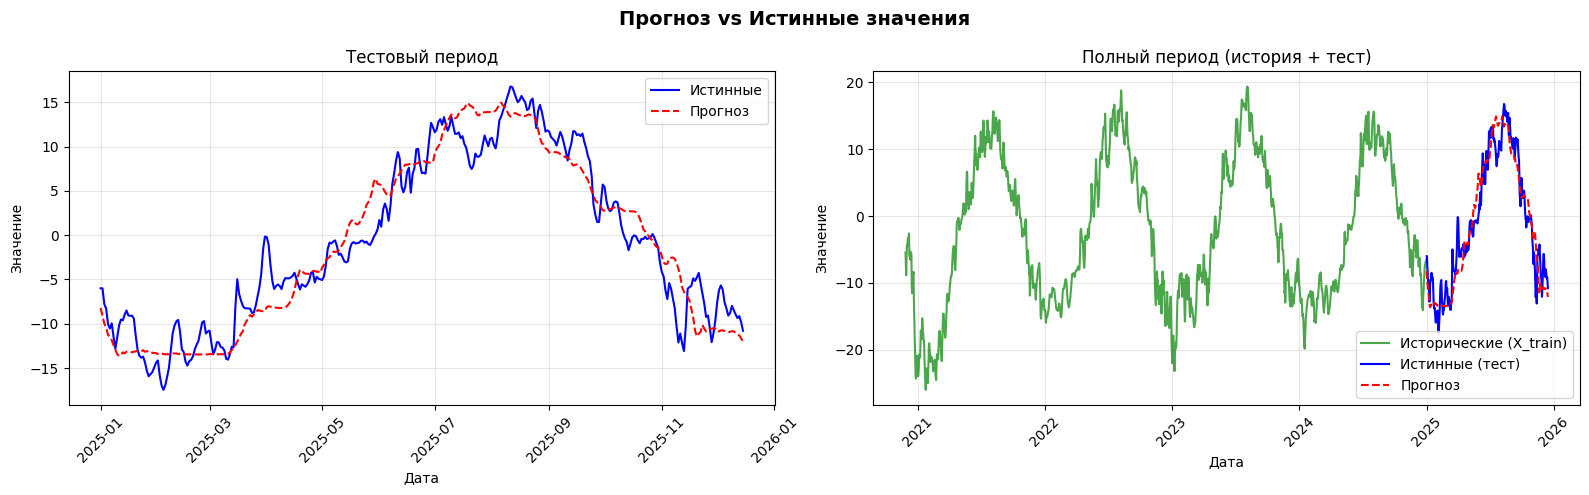

           feature  importance
5        Месяц_cos    0.352423
0   48-1 (0)_lag_1    0.177421
1   48-1 (0)_lag_2    0.147816
2   48-1 (0)_lag_3    0.133746
7  day_of_year_cos    0.082775
3   48-1 (1)_lag_1    0.040091
4        Месяц_sin    0.035426
6  day_of_year_sin    0.030302
48-1 (1)
RMSE на тесте = 1.2931062401336666


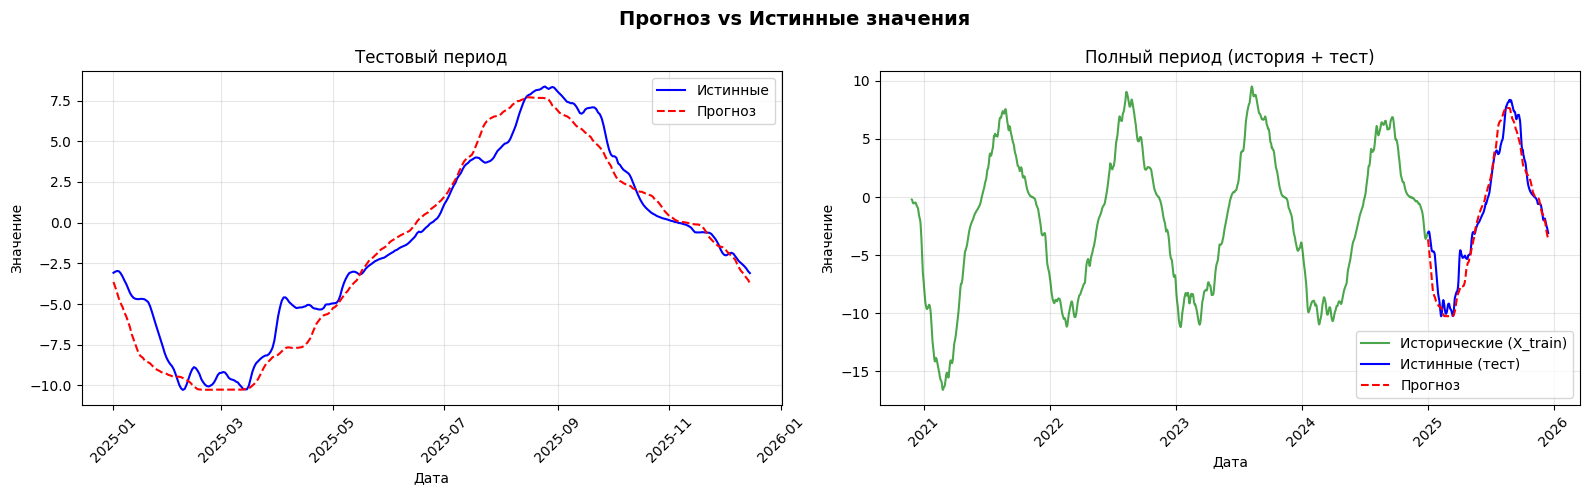

            feature  importance
2    48-1 (0)_lag_3    0.127705
1    48-1 (0)_lag_2    0.114986
3    48-1 (1)_lag_1    0.111083
4    48-1 (1)_lag_2    0.108239
0    48-1 (0)_lag_1    0.093216
6    48-1 (2)_lag_1    0.088738
8    48-1 (2)_lag_3    0.075956
7    48-1 (2)_lag_2    0.066882
10        Месяц_cos    0.059258
5    48-1 (1)_lag_3    0.058533
11  day_of_year_sin    0.044393
9         Месяц_sin    0.033267
12  day_of_year_cos    0.017744
48-1 (2)
RMSE на тесте = 0.8577132000467643


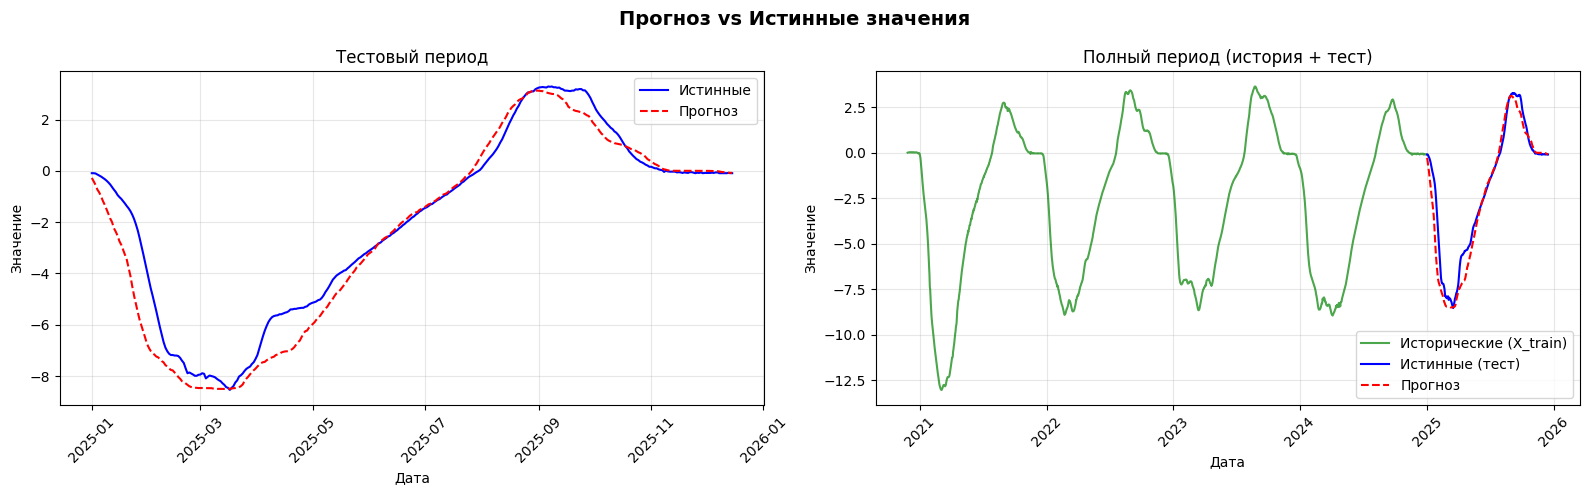

            feature  importance
6    48-1 (3)_lag_2    0.143813
9   day_of_year_sin    0.142478
4    48-1 (2)_lag_3    0.141001
3    48-1 (2)_lag_2    0.136329
2    48-1 (2)_lag_1    0.127911
5    48-1 (3)_lag_1    0.111288
7         Месяц_sin    0.110338
1    48-1 (1)_lag_2    0.039593
0    48-1 (1)_lag_1    0.017465
8         Месяц_cos    0.016471
10  day_of_year_cos    0.013312
48-1 (3)
RMSE на тесте = 0.6106006232626913


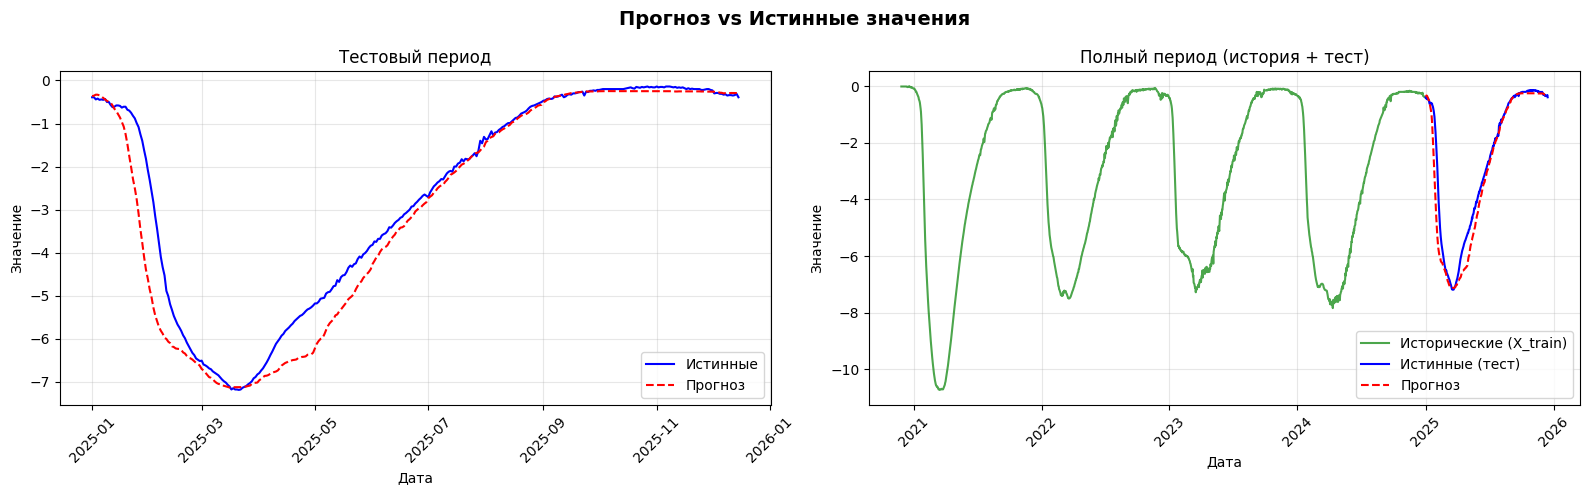

           feature  importance
8  day_of_year_sin    0.169370
3   48-1 (4)_lag_1    0.160554
4   48-1 (4)_lag_2    0.158015
6        Месяц_sin    0.139750
5   48-1 (4)_lag_3    0.126381
1   48-1 (3)_lag_1    0.092423
2   48-1 (3)_lag_2    0.082035
0   48-1 (2)_lag_1    0.043081
9  day_of_year_cos    0.015271
7        Месяц_cos    0.013120
48-1 (4)
RMSE на тесте = 0.5126077150551903


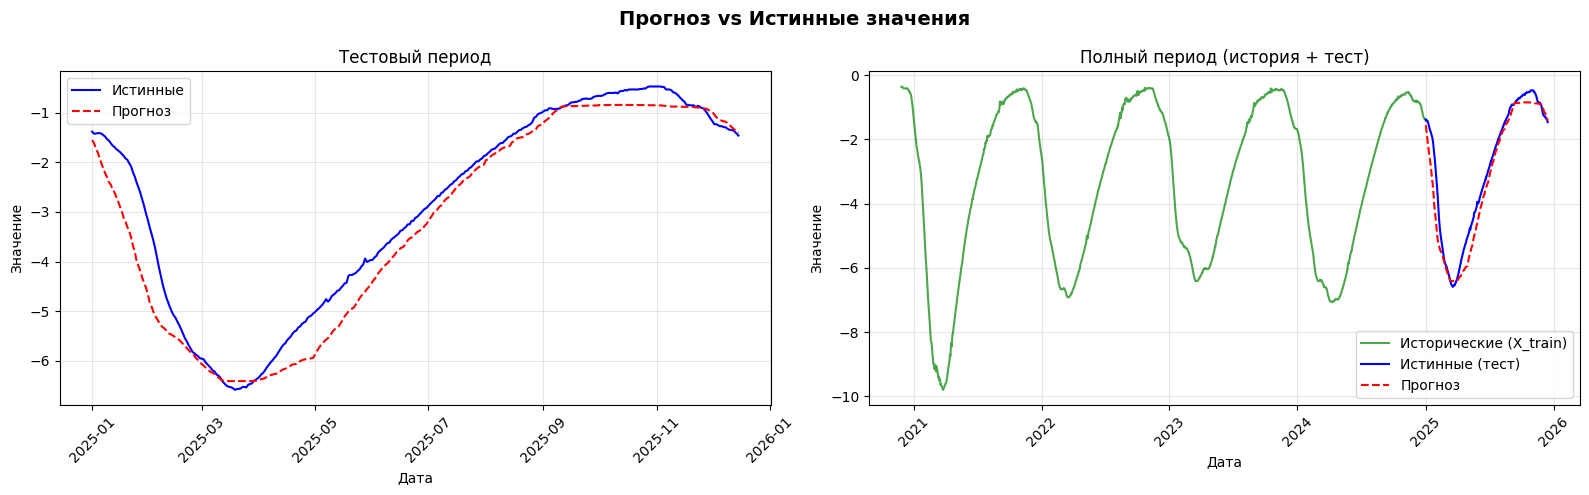

           feature  importance
5        Месяц_sin    0.200355
7  day_of_year_sin    0.197625
4   48-1 (5)_lag_2    0.133382
0   48-1 (3)_lag_1    0.126015
3   48-1 (5)_lag_1    0.124901
1   48-1 (4)_lag_1    0.110950
2   48-1 (4)_lag_2    0.073284
6        Месяц_cos    0.019432
8  day_of_year_cos    0.014057
48-1 (5)
RMSE на тесте = 0.5004132887444804


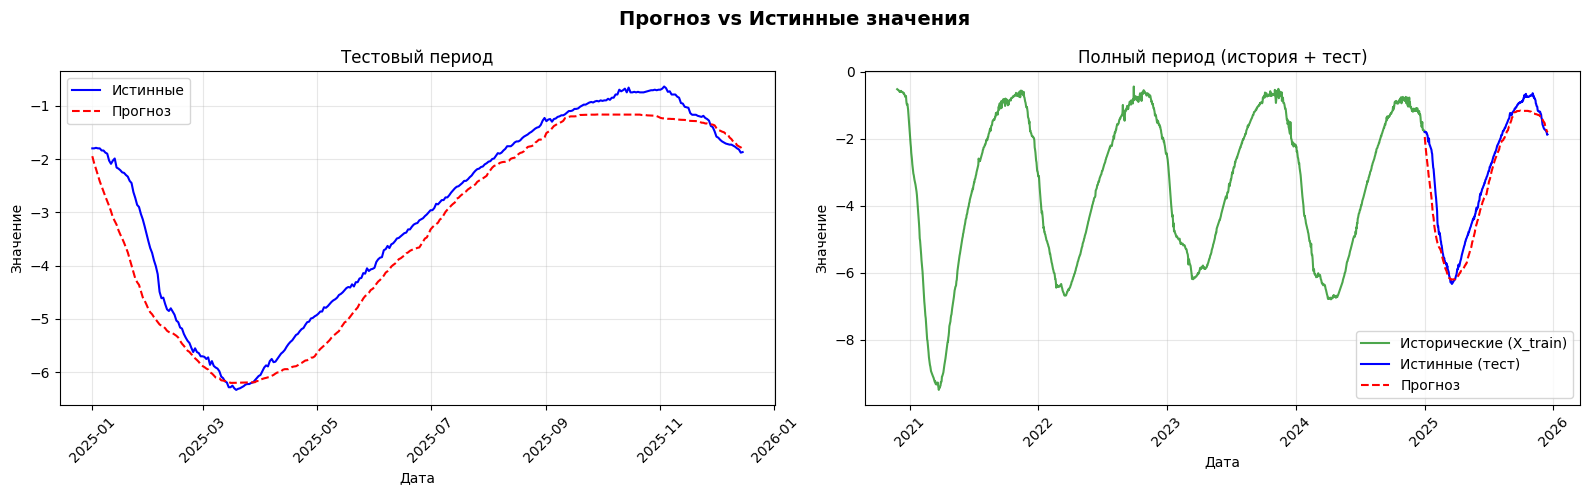

           feature  importance
5        Месяц_sin    0.315337
4   48-1 (6)_lag_3    0.151057
3   48-1 (6)_lag_2    0.138794
0   48-1 (4)_lag_1    0.104266
7  day_of_year_sin    0.088004
2   48-1 (6)_lag_1    0.087935
1   48-1 (5)_lag_1    0.087311
6        Месяц_cos    0.014262
8  day_of_year_cos    0.013033
48-1 (6)
RMSE на тесте = 0.4753838750267267


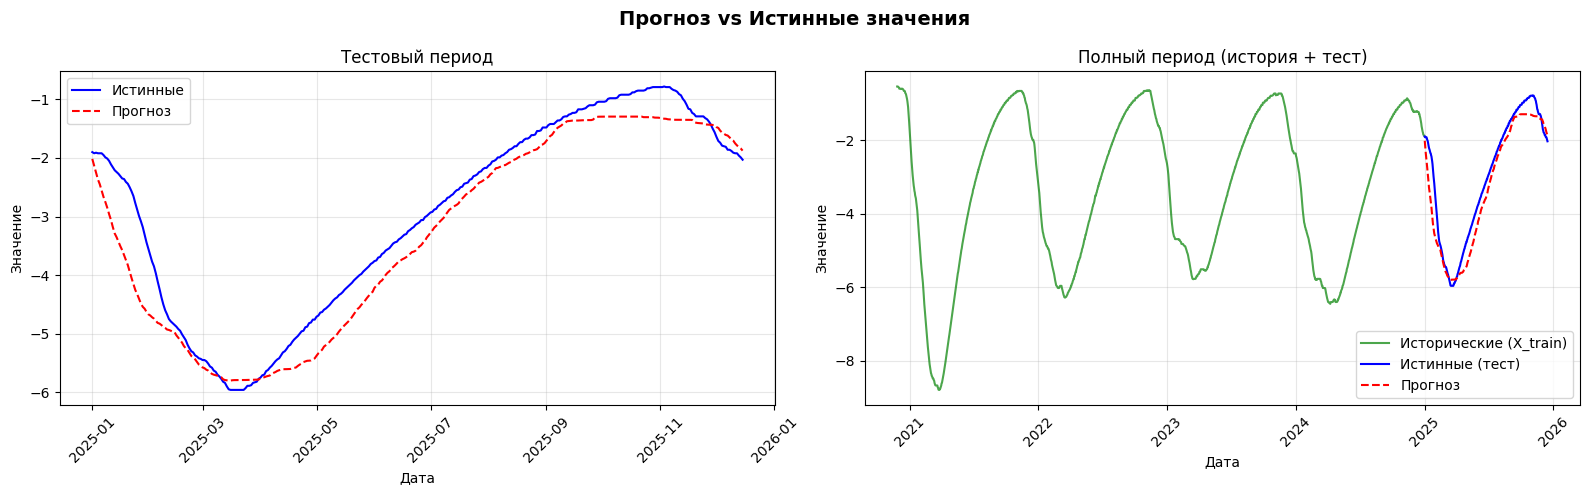

            feature  importance
6    48-1 (6)_lag_4    0.193468
5    48-1 (6)_lag_3    0.121459
8    48-1 (7)_lag_1    0.118573
2    48-1 (5)_lag_3    0.113027
4    48-1 (6)_lag_2    0.094012
7    48-1 (6)_lag_5    0.088616
3    48-1 (6)_lag_1    0.081504
0    48-1 (5)_lag_1    0.071661
1    48-1 (5)_lag_2    0.057863
11  day_of_year_sin    0.054817
9         Месяц_sin    0.002275
12  day_of_year_cos    0.001938
10        Месяц_cos    0.000788
48-1 (7)
RMSE на тесте = 0.4400071945313449


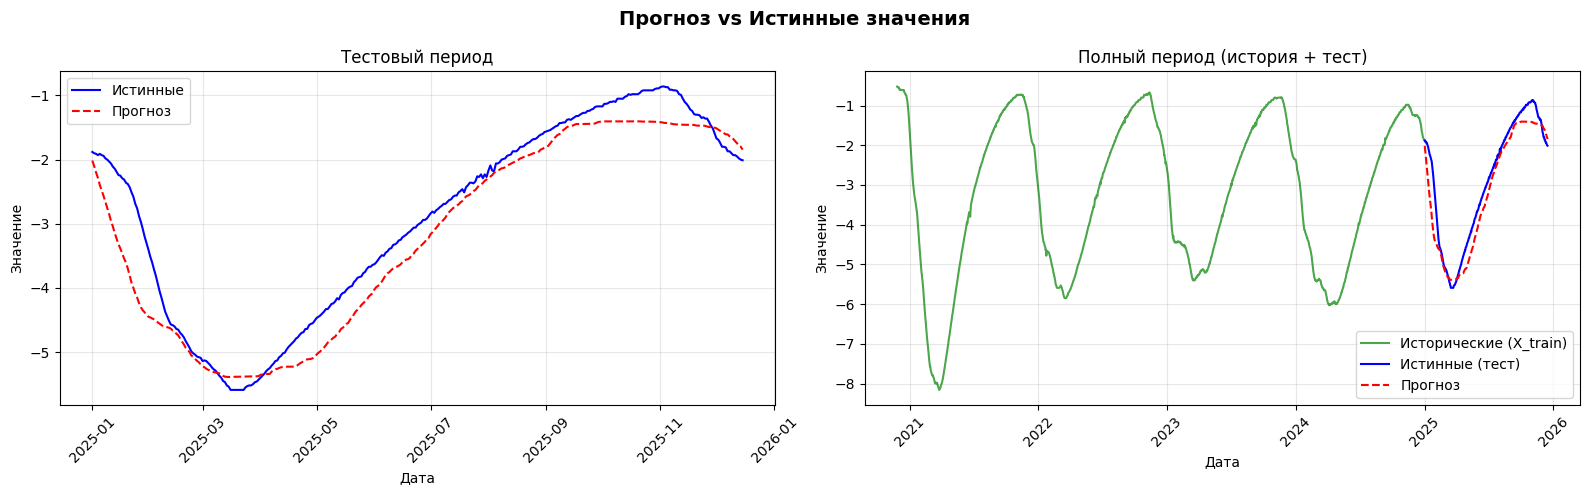

            feature  importance
5    48-1 (7)_lag_4    0.176786
4    48-1 (7)_lag_3    0.173877
7    48-1 (8)_lag_1    0.117689
2    48-1 (7)_lag_1    0.115115
6    48-1 (7)_lag_5    0.099343
3    48-1 (7)_lag_2    0.087216
0    48-1 (6)_lag_1    0.076572
8         Месяц_sin    0.076214
1    48-1 (6)_lag_2    0.053747
10  day_of_year_sin    0.021360
11  day_of_year_cos    0.001319
9         Месяц_cos    0.000761
48-1 (8)
RMSE на тесте = 0.3745355440956268


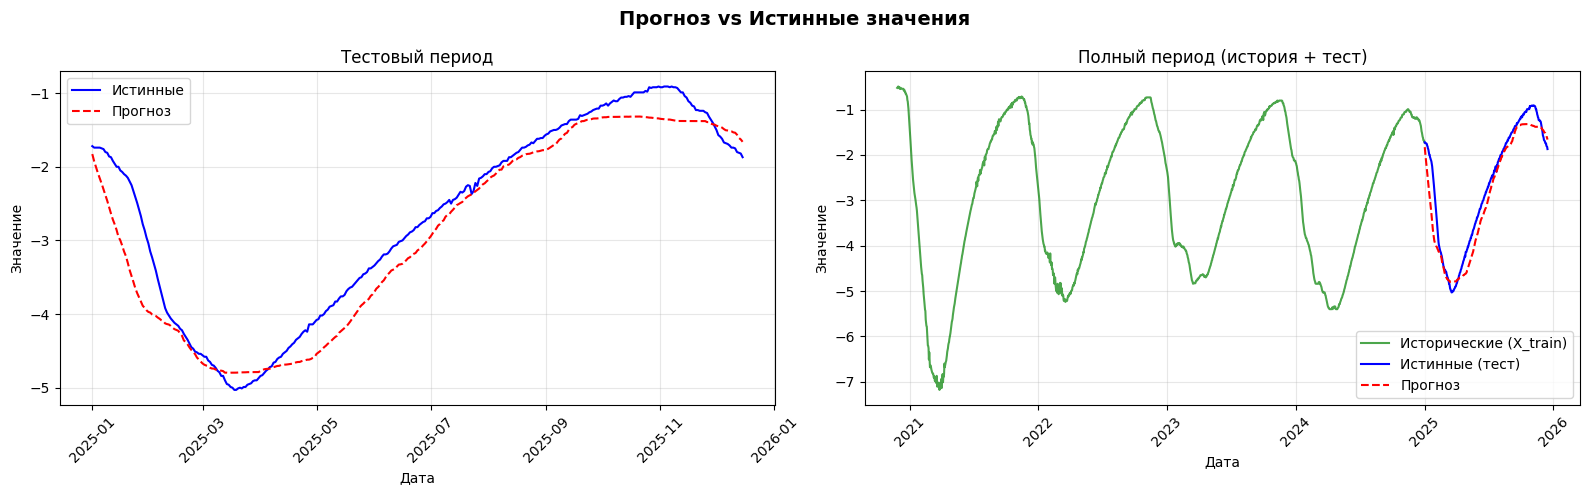

            feature  importance
3    48-1 (8)_lag_3    0.139397
7    48-1 (9)_lag_2    0.136640
2    48-1 (8)_lag_2    0.133405
0    48-1 (7)_lag_1    0.127994
6    48-1 (9)_lag_1    0.120280
1    48-1 (8)_lag_1    0.115577
4    48-1 (8)_lag_4    0.086132
5    48-1 (8)_lag_5    0.083246
10  day_of_year_sin    0.040650
8         Месяц_sin    0.011856
11  day_of_year_cos    0.003631
9         Месяц_cos    0.001192
48-1 (9)
RMSE на тесте = 0.2659661006137499


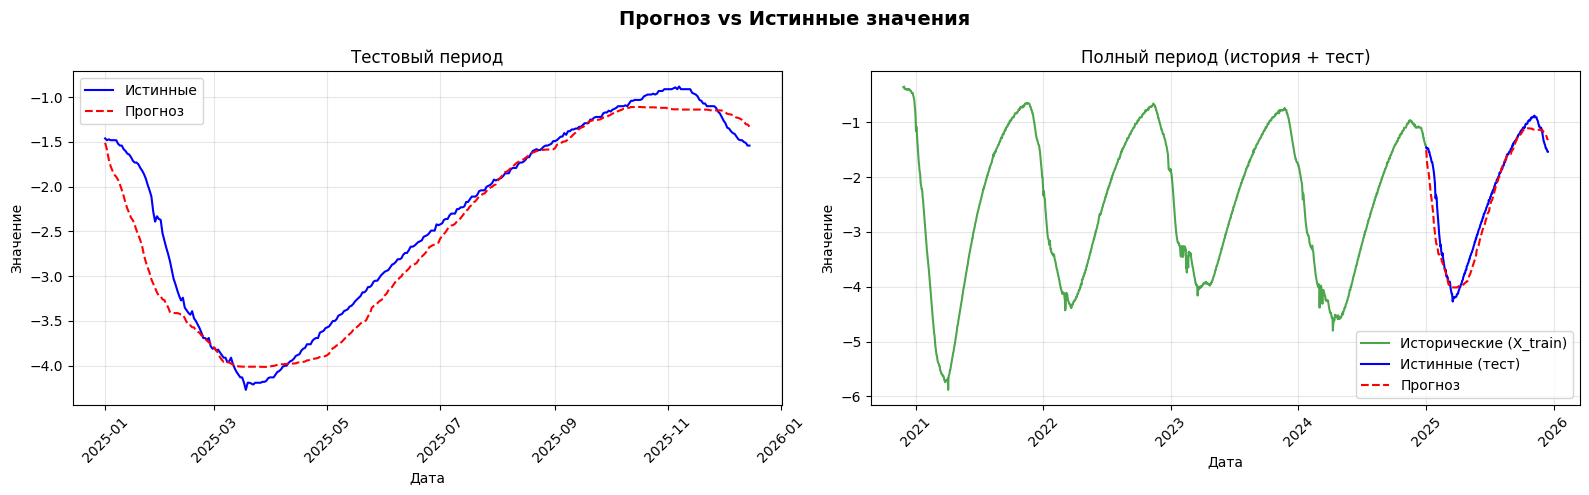

           feature  importance
5        Месяц_sin    0.177267
7  day_of_year_sin    0.168912
2   48-1 (9)_lag_2    0.135705
4  48-1 (10)_lag_2    0.135395
1   48-1 (9)_lag_1    0.120843
3  48-1 (10)_lag_1    0.119222
0   48-1 (8)_lag_1    0.111367
6        Месяц_cos    0.016132
8  day_of_year_cos    0.015158
48-1 (10)
RMSE на тесте = 0.16263137581875275


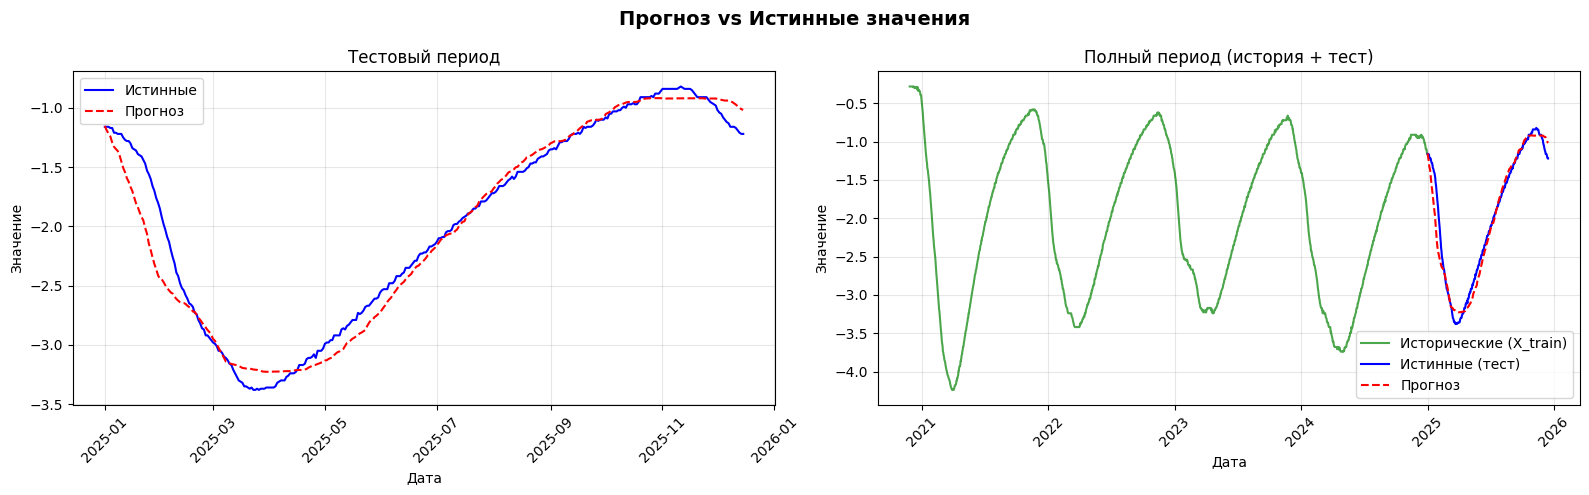

           feature  importance
4        Месяц_sin    0.435731
1  48-1 (10)_lag_1    0.144901
3  48-1 (10)_lag_3    0.102719
2  48-1 (10)_lag_2    0.101790
6  day_of_year_sin    0.097631
0   48-1 (9)_lag_1    0.078643
7  day_of_year_cos    0.022588
5        Месяц_cos    0.015997


In [12]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)